# Predicting Functional Outcomes at Discharge from Admission Data in Neurological Rehabilitation Patients

## Research Question

How well can machine learning predict discharge Barthel Index(BI) from clinical and functional information available at admission?

## Project Overview

Functional outcome is an important part of neurological rehabilitation. In this project, I used machine learning to predict the Barthel Index (BI) at discharge using information that was available when the patient entered rehabilitation.

I wanted to see how much information about the patient's initial functional status, clinical characteristics, and neurological condition can help us predict their functional status at discharge.

The main goals of this project were:

- to examine the relationship between admission and discharge BI;
- to compare different machine learning models for predicting discharge BI;
- to see whether information other than admission BI can improve the prediction; and
- to identify which admission variables are most important for the prediction.

## Dataset

In this project, I used the neurological subset of the rehabilitation dataset published by Seccia et al [1]. It contains data from 1,575 patients and 76 variables.

The dataset includes demographic information, neurological diagnoses, comorbidities, different types of impairments, and Barthel Index measurements at admission and discharge.

The target variable in this project is the discharge Barthel Index (`COD_26`). Since the aim is to make a prediction based on information available at admission, only admission-related information was used as predictors.

## 1. Load the Dataset

I first loaded the neurological rehabilitation dataset and checked its basic structure, including the number of patients, variables, data types, and missing values.

### note

The dataset is not included in this repository.
Please download it from the original source and place `neurological.csv` in the project folder before running this notebook.

In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv("Neurological.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1575, 76)


,Sex,Age,MaritalStatus_alone,MaritalStatus_notAlone,LevelOfEducation_high,LevelOfEducation_low,COD_1_Cat_1,COD_1_Cat_2,COD_1_Cat_3,COD_1_Cat_4,...,COD_26_2,COD_26_3,COD_26_4,COD_26_5,COD_26_6,COD_26_7,COD_26_8,COD_26_9,COD_26_10,COD_26_11
0,0,63,0,1,1,0,0,0,0,0,...,3.0,3.0,5.0,8.0,8.0,5.0,8.0,8.0,2.0,NaN
1,0,66,1,0,1,0,0,0,1,0,...,5.0,5.0,10.0,10.0,10.0,10.0,15.0,15.0,10.0,NaN
2,1,69,1,0,0,1,0,0,1,0,...,1.0,1.0,2.0,2.0,0.0,2.0,3.0,0.0,0.0,3.0
3,1,77,0,1,1,0,0,0,0,0,...,1.0,3.0,5.0,10.0,8.0,5.0,8.0,3.0,0.0,NaN
4,0,82,0,1,0,1,0,0,1,0,...,5.0,5.0,10.0,10.0,10.0,10.0,15.0,12.0,10.0,NaN


### Basic Dataset Information

we can see that the dataset contains 1,575 patients(rows) and 76 variables(columns). Before building the prediction models, I checked the data types and missing values to understand how the variables are stored.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1575 entries, 0 to 1574
Data columns (total 76 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sex                     1575 non-null   int64  
 1   Age                     1575 non-null   int64  
 2   MaritalStatus_alone     1575 non-null   int64  
 3   MaritalStatus_notAlone  1575 non-null   int64  
 4   LevelOfEducation_high   1575 non-null   int64  
 5   LevelOfEducation_low    1575 non-null   int64  
 6   COD_1_Cat_1             1575 non-null   int64  
 7   COD_1_Cat_2             1575 non-null   int64  
 8   COD_1_Cat_3             1575 non-null   int64  
 9   COD_1_Cat_4             1575 non-null   int64  
 10  COD_1_Cat_5             1575 non-null   int64  
 11  COD_1_Cat_6             1575 non-null   int64  
 12  COD_1_Cat_7             1575 non-null   int64  
 13  COD_1_Cat_8             1575 non-null   int64  
 14  COD_1_Cat_9             1575 non-null   int64  
 15

In [6]:
df.isnull().sum().sort_values(ascending=False).head(10)

COD_26_11                1429
Sex                         0
MaritalStatus_alone         0
Age                         0
LevelOfEducation_high       0
LevelOfEducation_low        0
COD_1_Cat_1                 0
COD_1_Cat_2                 0
COD_1_Cat_3                 0
COD_1_Cat_4                 0
dtype: int64

## 2. Understanding the Variables and Target

The dataset contains different types of information about the patients, including demographic characteristics, diagnoses, comorbidities, impairments, and Barthel Index measurements.

For this project, I focused on information that would be available at admission. The discharge Barthel Index was used as the target variable.

| Variable group | Examples | Role in the project |
|---|---|---|
| Demographic | Sex, Age | Predictors |
| Social | Marital status, Education | Predictors |
| Diagnosis | Main neurological diagnosis | Predictors |
| Comorbidities | Neurological, cardiovascular, metabolic conditions | Predictors |
| Impairments | Cognitive, communication, manipulation, balance, etc. | Predictors |
| Admission function | Admission Barthel Index (`COD_25`) | Predictor |
| Discharge function | Discharge Barthel Index (`COD_26`) | Target |

### Defining the Prediction Problem

The target variable is `COD_26`, which represents the Barthel Index at discharge.

I used `COD_25`, the admission Barthel Index, as one of the predictors because it is available at the beginning of rehabilitation.

I excluded the individual admission BI components (`COD_25_1` to `COD_25_11`) because they are components of the total admission BI. Using both the total score and its components would provide largely duplicated information.

All discharge variables were also excluded from the predictors because they would not be available when making a prediction at admission.

In [8]:
y = df["COD_26"]

exclude_cols = (
    ["COD_26"]
    + [col for col in df.columns if col.startswith("COD_26_")]
    + [col for col in df.columns if col.startswith("COD_25_")]
    + [
        "COD_1_Cat_6",
        "COD_1_Cat_8",
        "COD_1_Cat_9",
        "COD_3-10_Cat_17"
    ]
)

X = df.drop(columns=exclude_cols)

print("Predictors:", X.shape)
print("Target:", y.shape)

Predictors: (1575, 49)
Target: (1575,)


## 3. Exploratory Data Analysis

Before training the models, I explored the distribution of the admission and discharge Barthel Index and their relationship.

### Barthel Index Distribution

The admission BI ranges from 10 to 49 in this dataset, while the discharge BI ranges from 10 to 100. The discharge scores also show a ceiling at 100, which represents full independence.

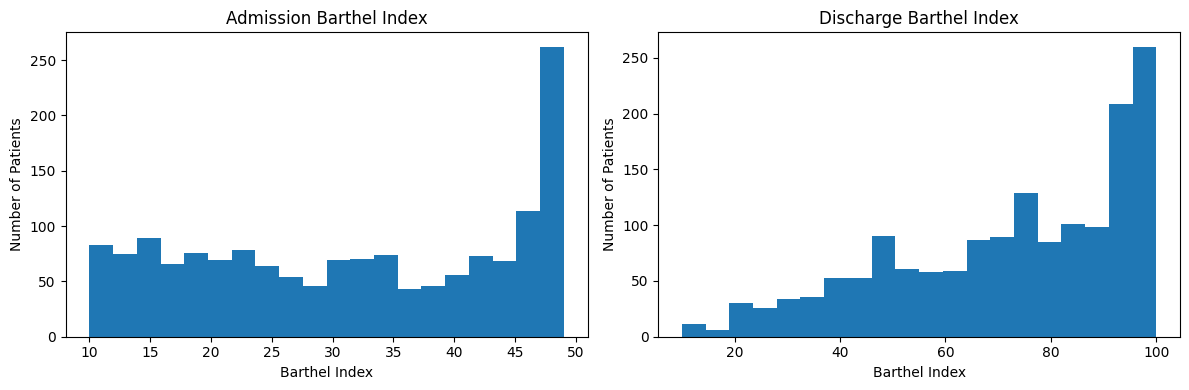

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["COD_25"], bins=20)
axes[0].set_title("Admission Barthel Index")
axes[0].set_xlabel("Barthel Index")
axes[0].set_ylabel("Number of Patients")

axes[1].hist(df["COD_26"], bins=20)
axes[1].set_title("Discharge Barthel Index")
axes[1].set_xlabel("Barthel Index")
axes[1].set_ylabel("Number of Patients")

plt.tight_layout()
plt.show()

### Admission and Discharge Functional Status

I then examined the relationship between admission and discharge BI. Patients with higher admission BI generally also had higher discharge BI, although there was considerable variation between patients.

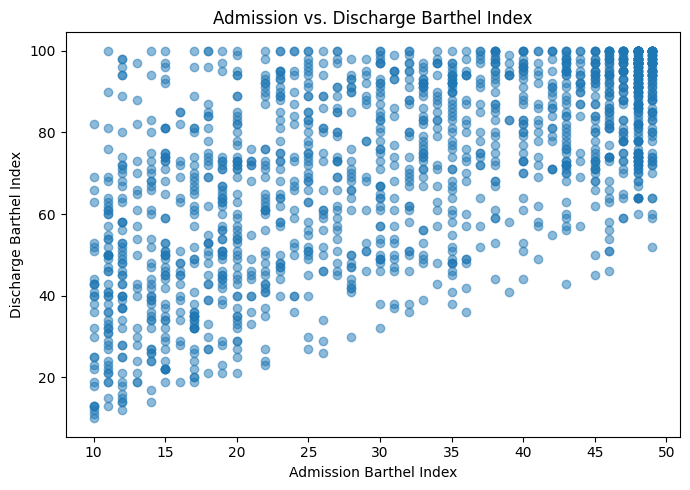

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(df["COD_25"], df["COD_26"], alpha=0.5)

plt.xlabel("Admission Barthel Index")
plt.ylabel("Discharge Barthel Index")
plt.title("Admission vs. Discharge Barthel Index")

plt.tight_layout()
plt.show()

In [13]:
correlation = df["COD_25"].corr(df["COD_26"])

print(f"Correlation between admission and discharge BI: {correlation:.3f}")

Correlation between admission and discharge BI: 0.632


## 4. Preparing the Data for Modeling

I separated the predictors from the target and divided the dataset into training and test sets.

The test set was kept separate from model training so that I could evaluate how well the models perform on data they have not seen before.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1260, 49)
Test set: (315, 49)


## 5. Baseline Model

Before comparing machine learning models, I established a simple baseline.

The baseline predicts the mean discharge BI from the training set for every patient in the test set. This does not use any patient-specific information, so it provides a reference for evaluating the machine learning models.

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_prediction))
baseline_r2 = r2_score(y_test, baseline_prediction)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²: {baseline_r2:.3f}")

Baseline MAE: 19.90
Baseline RMSE: 23.43
Baseline R²: -0.005


## 6. Linear Regression Using Admission BI Only

I first built a simple Linear Regression model using only the admission Barthel Index.

This model helps me understand how much predictive information is contained in the patient's initial functional status before adding the other clinical variables.

In [16]:
from sklearn.linear_model import LinearRegression

X_train_bi = X_train[["COD_25"]]
X_test_bi = X_test[["COD_25"]]

lr_bi = LinearRegression()
lr_bi.fit(X_train_bi, y_train)

y_pred_bi = lr_bi.predict(X_test_bi)

bi_mae = mean_absolute_error(y_test, y_pred_bi)
bi_rmse = np.sqrt(mean_squared_error(y_test, y_pred_bi))
bi_r2 = r2_score(y_test, y_pred_bi)

print(f"MAE: {bi_mae:.2f}")
print(f"RMSE: {bi_rmse:.2f}")
print(f"R²: {bi_r2:.3f}")

MAE: 13.95
RMSE: 16.81
R²: 0.482


The model achieved an MAE of 13.95 and an R² of 0.482. This is a clear improvement compared with the mean baseline, showing that admission BI contains useful information for predicting discharge BI.

However, an R² of 0.482 also means that admission BI alone does not capture all of the variation in discharge outcomes. This suggests that other patient characteristics may provide additional information.

## 7. Linear Regression Using All Admission Variables

I then used all 49 admission predictors in a Linear Regression model.

This allows me to compare the performance of the full model with the simpler model based only on admission BI.

In [17]:
lr_full = LinearRegression()

lr_full.fit(X_train, y_train)

y_pred_lr = lr_full.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"MAE: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R²: {lr_r2:.3f}")

MAE: 13.36
RMSE: 16.38
R²: 0.509


### Comparison with Admission BI Only

Adding the other admission variables improved the model slightly. The R² increased from 0.482 to 0.509, while the MAE decreased from 13.95 to 13.36.

This suggests that the additional demographic, diagnostic, and impairment-related variables provide some useful information, but admission BI still contains most of the predictive information.

## 8. Random Forest Regression

I next used a Random Forest Regressor with all admission predictors.

Random Forest can model nonlinear relationships and interactions between variables, so I wanted to see whether it could improve the prediction compared with Linear Regression.

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²: {rf_r2:.3f}")

MAE: 12.91
RMSE: 16.11
R²: 0.524


### Checking Model Generalization

Although the Random Forest performed slightly better on the test set, I also checked its performance on the training data.

A large difference between training and test performance can indicate overfitting.

In [19]:
y_pred_rf_train = rf.predict(X_train)

rf_train_mae = mean_absolute_error(y_train, y_pred_rf_train)
rf_train_r2 = r2_score(y_train, y_pred_rf_train)

print(f"Training MAE: {rf_train_mae:.2f}")
print(f"Training R²: {rf_train_r2:.3f}")

print(f"\nTest MAE: {rf_mae:.2f}")
print(f"Test R²: {rf_r2:.3f}")

Training MAE: 4.89
Training R²: 0.924

Test MAE: 12.91
Test R²: 0.524


The Random Forest showed a large difference between training and test performance. The training R² was 0.924, while the test R² was only 0.524.

This suggests that the model was overfitting the training data. I therefore decided to restrict the complexity of the Random Forest and evaluate whether this would improve its generalization.

In [20]:
max_depth=5
min_samples_split=20
min_samples_leaf=10

## 10. Reducing Overfitting

The original Random Forest showed clear overfitting. I therefore reduced the complexity of the trees by limiting their depth and requiring more observations for splitting and creating leaf nodes.

The goal was to improve the model's ability to generalize to unseen patients.

In [21]:
rf_regularized = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_regularized.fit(X_train, y_train)

y_pred_rf_reg = rf_regularized.predict(X_test)

reg_mae = mean_absolute_error(y_test, y_pred_rf_reg)
reg_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_reg))
reg_r2 = r2_score(y_test, y_pred_rf_reg)

print(f"Test MAE: {reg_mae:.2f}")
print(f"Test RMSE: {reg_rmse:.2f}")
print(f"Test R²: {reg_r2:.3f}")

Test MAE: 12.96
Test RMSE: 15.90
Test R²: 0.537


In [22]:
y_pred_reg_train = rf_regularized.predict(X_train)

reg_train_mae = mean_absolute_error(y_train, y_pred_reg_train)
reg_train_r2 = r2_score(y_train, y_pred_reg_train)

print(f"Training MAE: {reg_train_mae:.2f}")
print(f"Training R²: {reg_train_r2:.3f}")

print(f"\nTest MAE: {reg_mae:.2f}")
print(f"Test R²: {reg_r2:.3f}")

Training MAE: 12.10
Training R²: 0.551

Test MAE: 12.96
Test R²: 0.537


The regularized Random Forest had much closer training and test performance than the original model. The test R² also increased from 0.524 to 0.537, while the test RMSE decreased from 16.11 to 15.90.

The MAE was very similar to the original Random Forest. Overall, the regularized model showed better generalization and was selected as the final model.

## 11. Model Comparison

I compared the models using MAE, RMSE, and R² on the same held-out test set.

- MAE shows the average absolute prediction error in BI points.
- RMSE gives more weight to larger prediction errors.
- R² shows how much of the variation in discharge BI is explained by the model.

In [23]:
results = pd.DataFrame({
    "Model": [
        "Mean baseline",
        "Linear Regression - Admission BI only",
        "Linear Regression - All admission variables",
        "Random Forest",
        "Regularized Random Forest"
    ],
    "MAE": [
        baseline_mae,
        bi_mae,
        lr_mae,
        rf_mae,
        reg_mae
    ],
    "RMSE": [
        baseline_rmse,
        bi_rmse,
        lr_rmse,
        rf_rmse,
        reg_rmse
    ],
    "R²": [
        baseline_r2,
        bi_r2,
        lr_r2,
        rf_r2,
        reg_r2
    ]
})

results.round(3)

,Model,MAE,RMSE,R²
0,Mean baseline,19.897,23.429,-0.005
1,Linear Regression - Admission BI only,13.954,16.813,0.482
2,Linear Regression - All admission variables,13.363,16.379,0.509
3,Random Forest,12.909,16.114,0.524
4,Regularized Random Forest,12.955,15.904,0.537


## 12. Model Interpretation

After selecting the regularized Random Forest as the final model, I examined the importance of the admission variables.

I used permutation importance because it measures how much the model performance changes when the values of one variable are randomly shuffled.

In [24]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_regularized,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance,Std
48,COD_25,8.269453,0.582364
12,COD_2_Cat_1,0.325184,0.101896
39,COD_15_healthy_sick,0.239683,0.113617
1,Age,0.165370,0.100062
44,COD_20_healthy_sick,0.153632,0.036484
13,COD_2_Cat_2,0.129133,0.104169
46,COD_22_healthy_sick,0.086731,0.018322
35,COD_11_healthy_sick,0.082395,0.071813
14,COD_2_Cat_3,0.077726,0.032113
7,COD_1_Cat_2,0.042154,0.017201


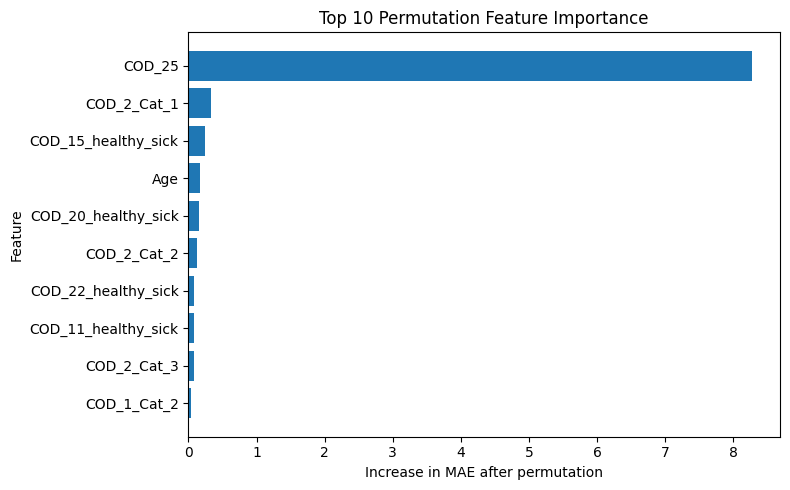

In [25]:
top_features = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Increase in MAE after permutation")
plt.ylabel("Feature")
plt.title("Top 10 Permutation Feature Importance")

plt.tight_layout()
plt.show()

### Interpretation of Feature Importance

Admission Barthel Index (`COD_25`) was clearly the most important predictor in the final model. Shuffling this variable caused a much larger increase in prediction error than shuffling the other variables.

Age, neurological diagnosis, and several impairment-related variables also contributed to the model, but their importance was much smaller.

This suggests that the patient's functional status at admission contains most of the predictive information in this dataset, while other clinical characteristics provide additional information.

Feature importance shows which variables are useful for the model's predictions, but it does not show that these variables cause better or worse rehabilitation outcomes.

## 13. Actual vs. Predicted Discharge BI

I compared the predicted discharge BI with the actual values in the test set.

If the predictions were perfect, all points would be close to the diagonal line. The distance from this line shows the prediction error for individual patients.

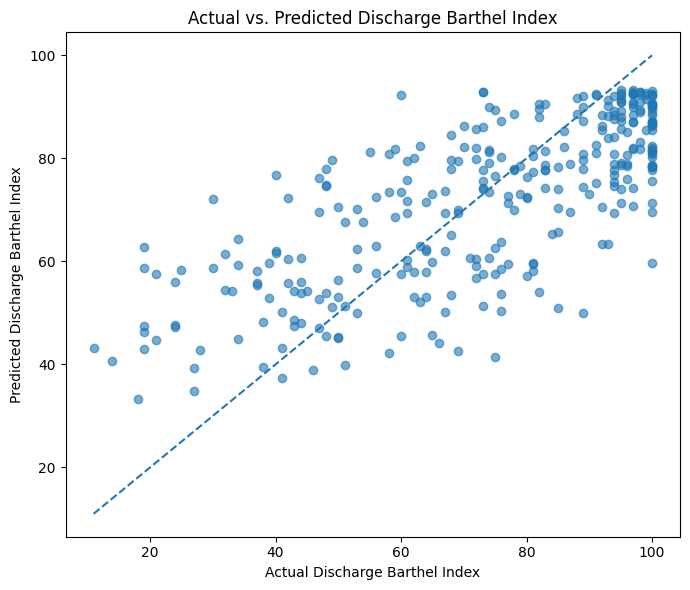

In [26]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_rf_reg,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Discharge Barthel Index")
plt.ylabel("Predicted Discharge Barthel Index")
plt.title("Actual vs. Predicted Discharge Barthel Index")

plt.tight_layout()
plt.show()

### Interpretation

The predictions generally follow the actual discharge BI values, showing that the model was able to capture part of the variation in functional outcomes.

However, the points are not all close to the diagonal line, which indicates that there is still considerable prediction error. The model also tends to underestimate some patients with higher discharge BI and overestimate some patients with lower discharge BI.

This is consistent with the test R² of 0.537 and MAE of about 13 BI points.

## 14. Residual Analysis

I also examined the residuals of the final model.

Residuals are the differences between the actual and predicted discharge BI. A good prediction model should not show a strong systematic pattern in these errors.

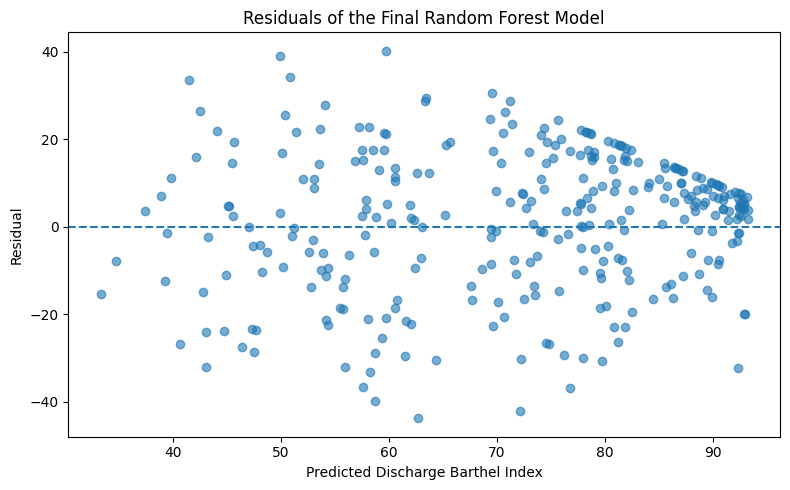

In [27]:
residuals = y_test - y_pred_rf_reg

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_rf_reg,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Discharge Barthel Index")
plt.ylabel("Residual")
plt.title("Residuals of the Final Random Forest Model")

plt.tight_layout()
plt.show()

### Interpretation

The residuals are spread around zero, but their spread is not completely uniform across the range of predictions.

This indicates that the model does not make equally accurate predictions for all patients. Some systematic variation remains in the prediction errors, which is expected given the moderate predictive performance of the model.

The residual plot also supports the conclusion that the model captures part, but not all, of the variation in discharge functional outcomes.

## 15. Results and Discussion

The results from the different models are summarized below.

In [28]:
results.round(3)

,Model,MAE,RMSE,R²
0,Mean baseline,19.897,23.429,-0.005
1,Linear Regression - Admission BI only,13.954,16.813,0.482
2,Linear Regression - All admission variables,13.363,16.379,0.509
3,Random Forest,12.909,16.114,0.524
4,Regularized Random Forest,12.955,15.904,0.537


### Main Findings

The mean baseline performed poorly, with an MAE of 19.90 BI points and an R² close to zero.

Using admission BI alone with Linear Regression produced a much better result, with an MAE of 13.95 and an R² of 0.482. Adding the other admission variables improved the R² to 0.509 and reduced the MAE to 13.36.

The Random Forest produced a further improvement, but the original model showed clear overfitting. After restricting the complexity of the trees, the regularized Random Forest achieved the best overall test R² of 0.537 and the lowest RMSE of 15.90. Its MAE was 12.96, which was very similar to the original Random Forest.

Overall, admission BI was by far the most important predictor. The other clinical and demographic variables provided additional information, but their contribution was much smaller.

### Limitations

An important limitation is that the dataset had already been processed by the original authors before I used it. Their cleaning procedure excluded some patients based on rehabilitation-related outcomes, including patients whose Barthel Index decreased or who showed no improvement in any BI component. Therefore, the dataset may not represent all patients receiving neurological rehabilitation.

Another limitation is that the models were evaluated using a single train-test split. Cross-validation and external validation on an independent patient population would provide a more robust assessment of model performance.

For these reasons, the model should not be considered a clinically validated prediction tool.

## 16. Conclusion

This project investigated whether machine learning could predict discharge Barthel Index from information available at admission in patients undergoing neurological rehabilitation.

The results showed that admission functional status was the strongest predictor of discharge functional status. Adding demographic, diagnostic, and impairment-related variables provided some additional predictive information. The regularized Random Forest achieved the best overall test performance, with an R² of 0.537 and an RMSE of 15.90.

However, the model should not be considered a clinical decision-making tool. The dataset had already been processed and selected by the original authors, and the model was evaluated using a single train-test split. External validation using independent rehabilitation populations would be needed before considering clinical application.

Overall, this project shows how routinely collected rehabilitation data can be used with conventional machine learning methods to investigate functional outcomes. It also gave me practical experience in preparing clinical data, comparing regression models, identifying overfitting, and interpreting model predictions.

## references  
[1] Seccia, et al. (2020). "Data of patients undergoing rehabilitation programs". Data in Brief, 30, Article 105419. https://doi.org/10.1016/j.dib.2020.105419